In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-churn-dataset/customer_churn_dataset-testing-master.csv
/kaggle/input/customer-churn-dataset/customer_churn_dataset-training-master.csv


### Customer Churn Prediction - End-to-End ML Pipeline


 Customer churn—also known as customer attrition—refers to the phenomenon where customers stop using a company’s product or service. In subscription-based businesses, churn is a critical metric: every lost customer represents lost revenue, increased acquisition costs, and potential damage to brand loyalty.

Understanding churn isn’t just about predicting who will leave—it's about uncovering why they leave. By analyzing behavioral patterns, support interactions, payment delays, and engagement signals, we can build models that not only forecast churn but also guide retention strategies.

In this notebook, we’ll explore a real-world dataset to:

Engineer meaningful features from customer behavior

Build and evaluate machine learning models

Interpret churn drivers using feature importance

Visualize churn risk to support actionable insights

In [2]:
import warnings 
warnings.filterwarnings('ignore') 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score 
from sklearn.preprocessing import StandardScaler,OneHotEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve 
import shap 
import joblib

In [3]:
#Load the Dataset
df = pd.read_csv("/kaggle/input/customer-churn-dataset/customer_churn_dataset-testing-master.csv")
print("Dataset Preview")
df.head()

Dataset Preview


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
print(30 * "=")
print("Exploratory Data Analysis(EDA)")
print(30 * "=")
print(f"Dataset Shape: ",df.shape)
print(50 * "=")
print(f"Dataset Info: \n",df.info())
print(50 * "=")
print(f"Descriptive Statistics: \n",df.describe().T)
print(50 * "=")
print(f"DataSet Columns: ",df.columns)
print(50 * "=")
missing = df.isna().sum()
missing_perc = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column':missing.index,
    'Percent':missing_perc.values
})
print(f"Missing Value Percent: \n{missing_df}")



Exploratory Data Analysis(EDA)
Dataset Shape:  (64374, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB
Dataset Info: 
 None
Descriptive Statistics: 
                     count          mean           std    min       25%  \
Cus

In [5]:
#Drop the CustomerID columns 
df = df.drop('CustomerID',axis=1)

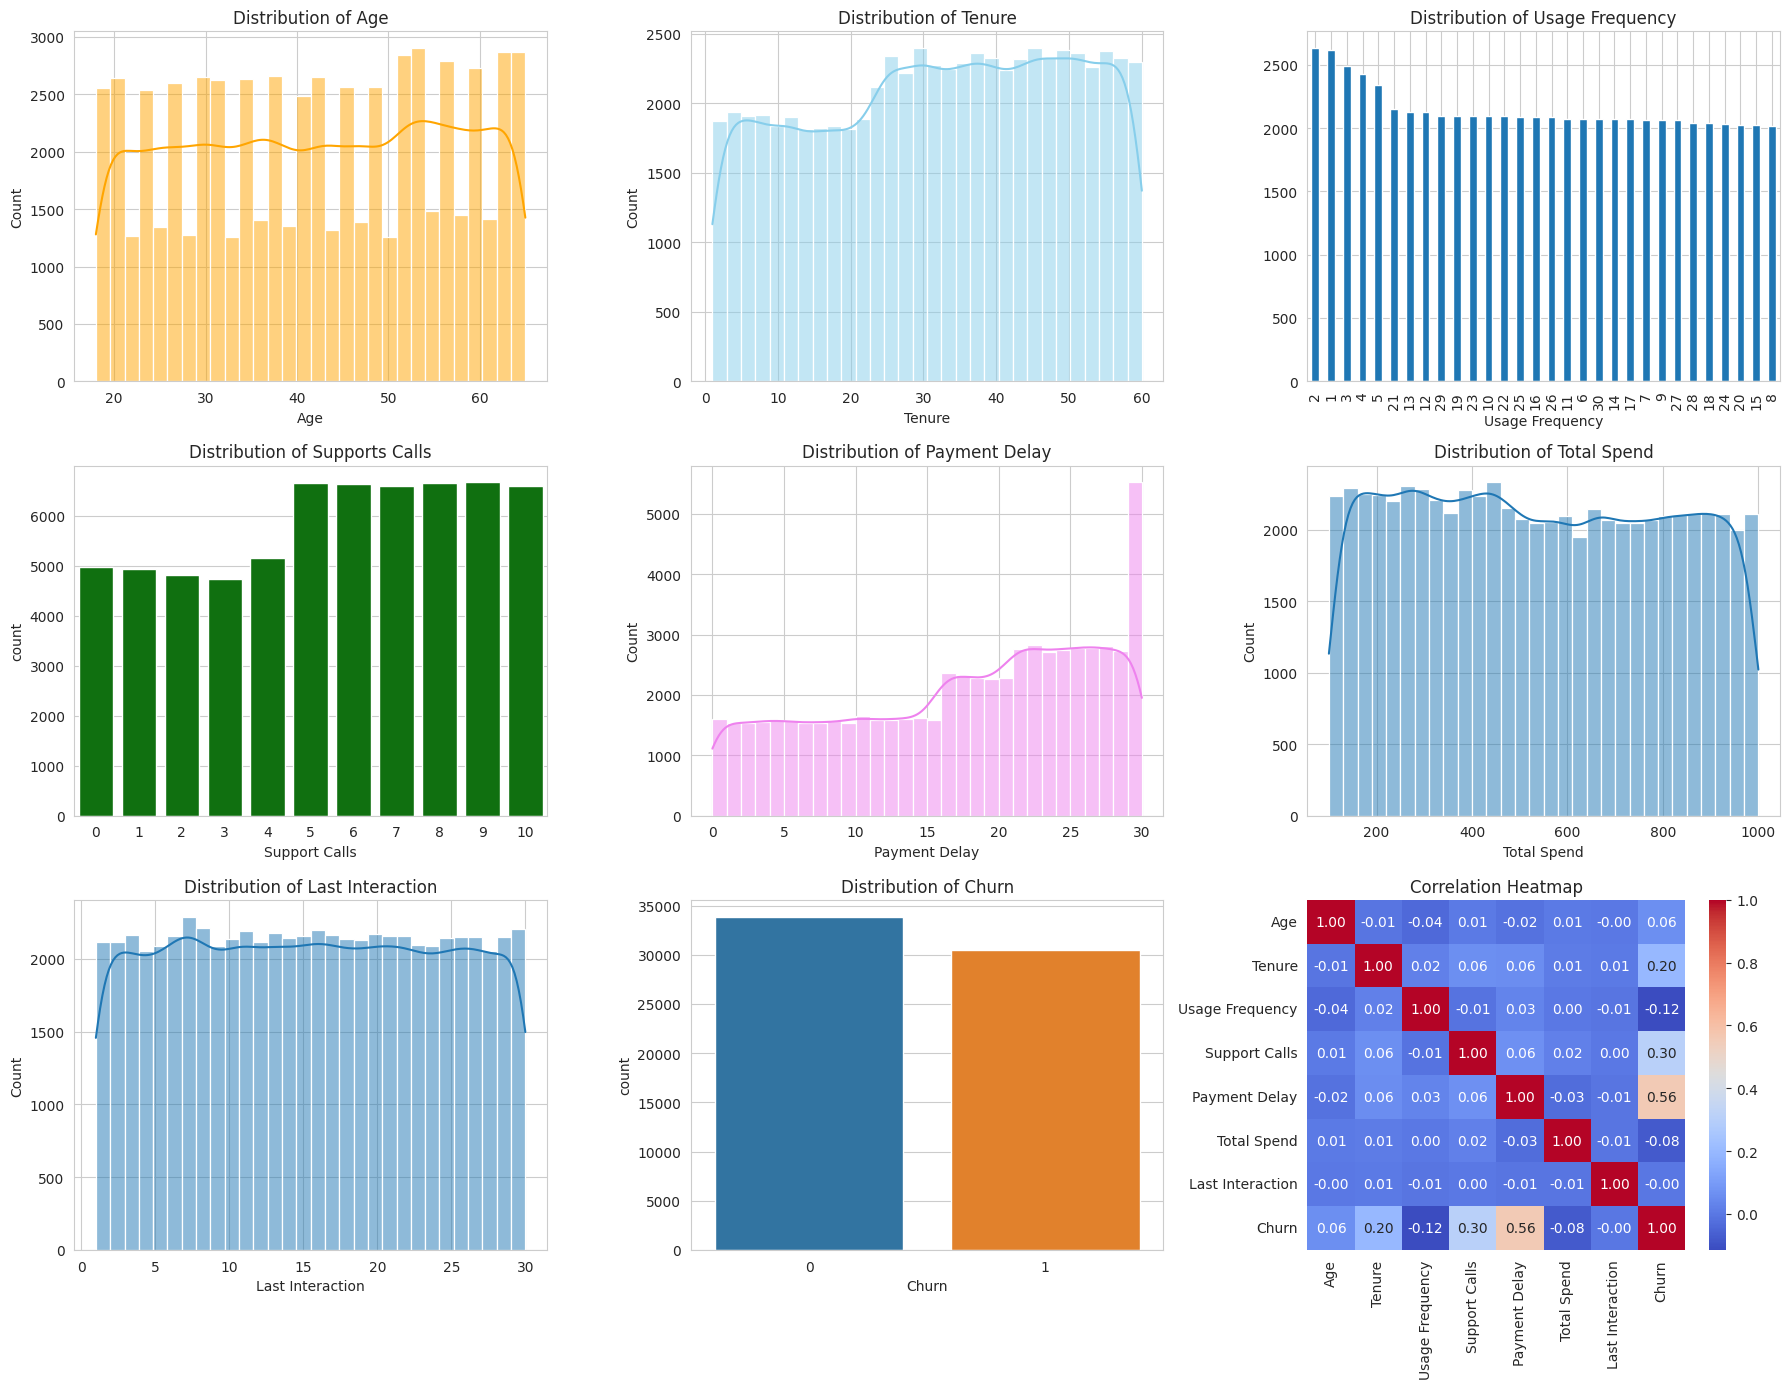

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
#set the Style 
sns.set_style("whitegrid")

#Arrangement of Diagrams
fig,axes = plt.subplots(3,3,figsize=(18,14))
axes = axes.flatten()

#Distribution of Age
sns.histplot(df['Age'],kde=True,bins=30,color='orange',ax=axes[0])
axes[0].set_title("Distribution of Age")

#Distribution of Tenure
sns.histplot(df['Tenure'],kde=True,bins=30,color='skyblue',ax=axes[1])
axes[1].set_title("Distribution of Tenure")

#Countplot for Usage Frequency
usage_freq = df['Usage Frequency'].value_counts()
usage_freq.plot(kind='bar',ax=axes[2])
axes[2].set_title("Distribution of Usage Frequency")

#Countplot for Support Calls
sns.countplot(x=df['Support Calls'],data=df,color='green',ax=axes[3])
axes[3].set_title("Distribution of Supports Calls")

#Distribution of Payment Delay
sns.histplot(df['Payment Delay'],kde=True,bins=30,color="violet",ax=axes[4])
axes[4].set_title("Distribution of Payment Delay")

#Distribution of Total Spend
sns.histplot(df['Total Spend'],kde=True,bins=30,palette='pastel',ax=axes[5])
axes[5].set_title("Distribution of Total Spend")

#Distribution of Last Interaction
sns.histplot(df['Last Interaction'],kde=True,bins=30,palette='viridis',ax=axes[6])
axes[6].set_title("Distribution of Last Interaction")

#countplot for churn
sns.countplot(x=df['Churn'],data=df,ax=axes[7])
axes[7].set_title("Distribution of Churn")

#Correlation heatmap
numeric_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',ax=axes[8])
axes[8].set_title("Correlation Heatmap")

plt.tight_layout()

In [7]:
#Save the EDA 
output_path = "Eda_summary.png"
fig.savefig(output_path,dpi=300,bbox_inches='tight')
print(f"Eda Saved: ",output_path)

Eda Saved:  Eda_summary.png


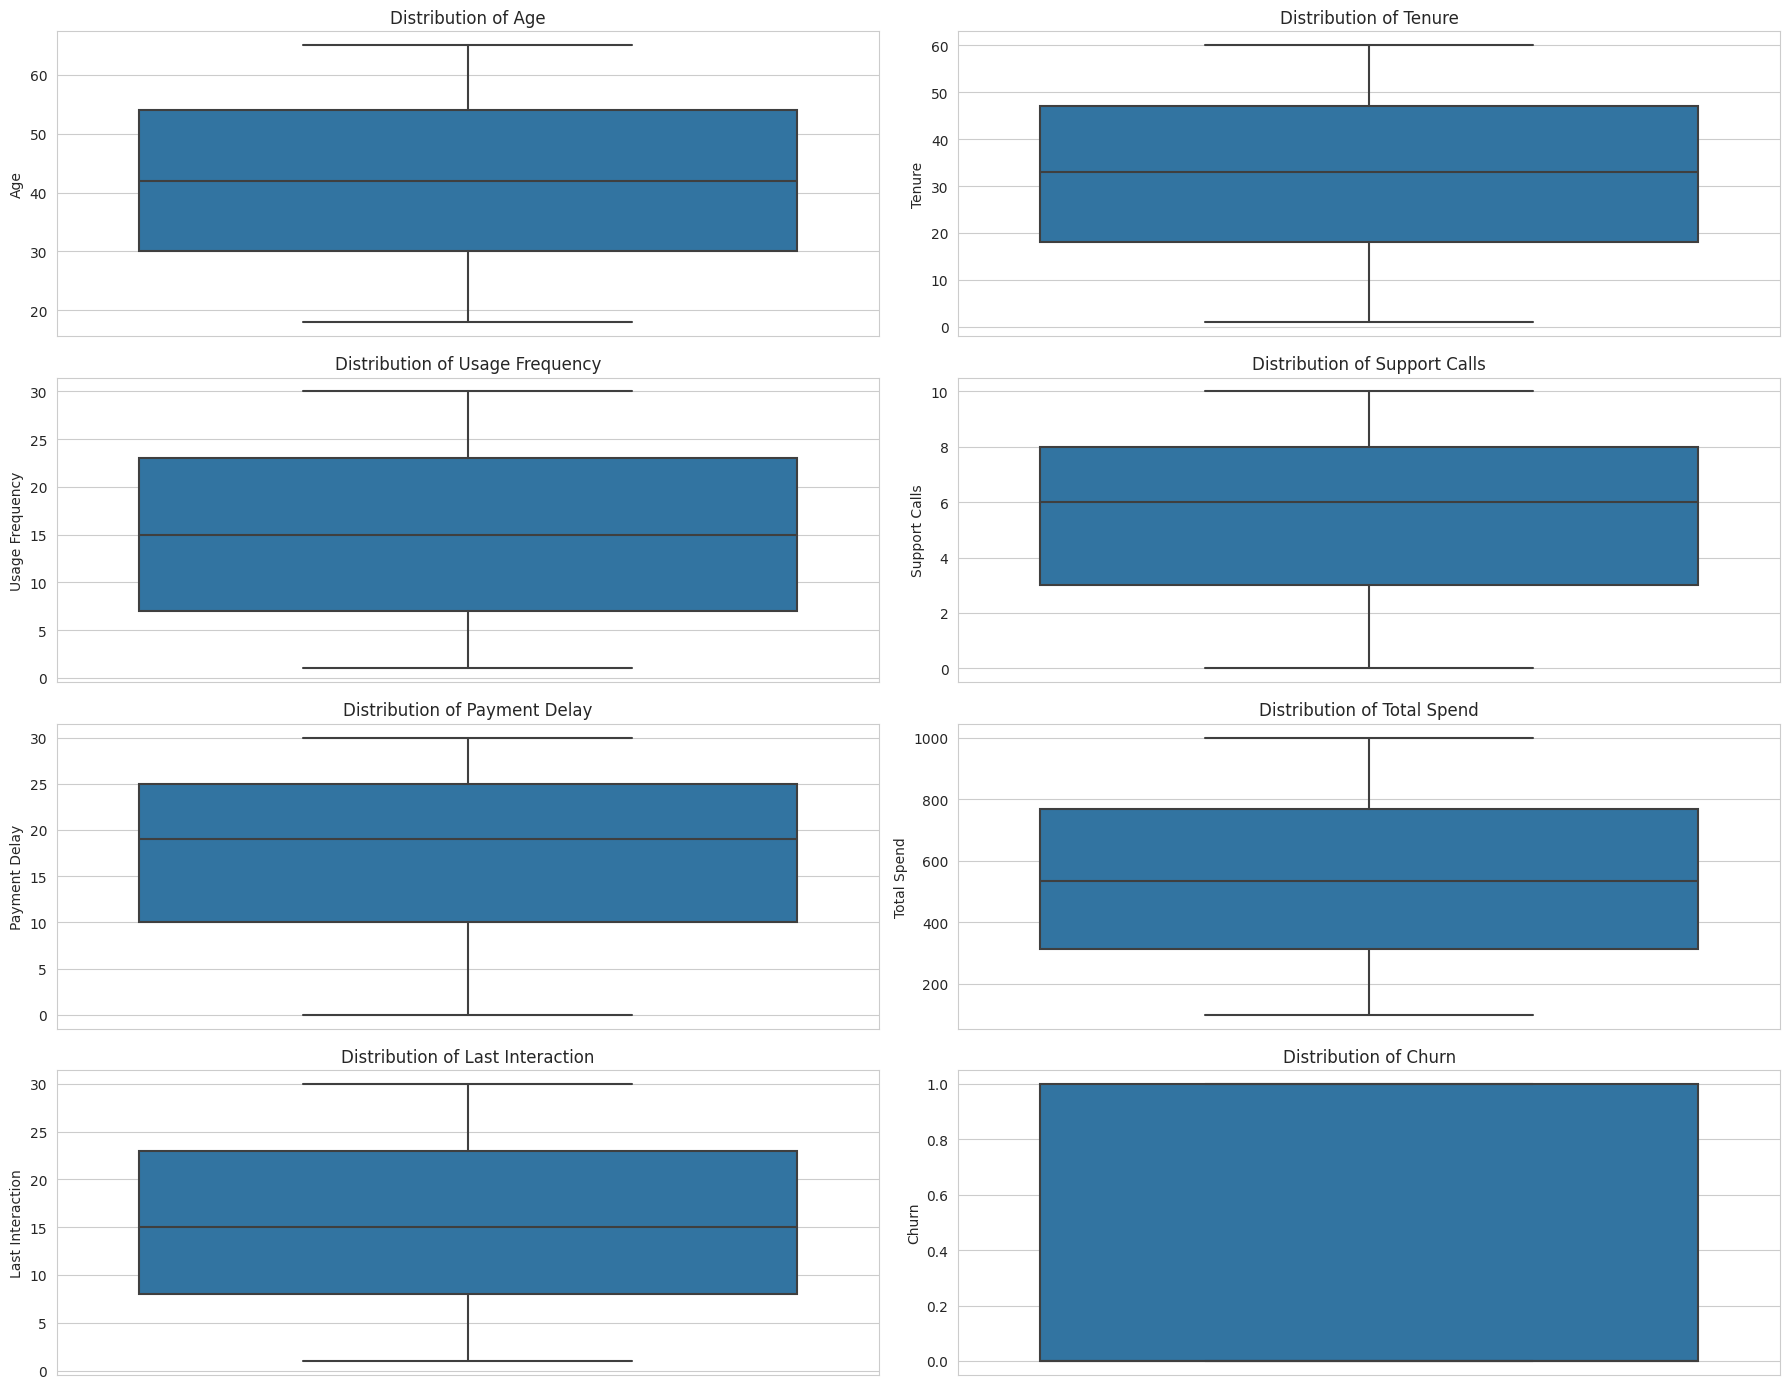

In [8]:
#get the numeric columns from the DataFrame
numeric_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
#Boxplot
fig,axes = plt.subplots(4,2,figsize=(18,14))
axes = axes.ravel()
for i,cols in enumerate(numeric_cols):    
    sns.boxplot(y=cols,data=df,ax=axes[i])
    axes[i].set_title(f"Distribution of {cols}")
    plt.tight_layout()
    

In [9]:
#Encode the Gender columns: Female = 1 ,Male = 0
df['Gender'] = df['Gender'].map({"Female":1,"Male":0})

#Encode the Contract Length 
contract_map = {"Monthly":1,"Quarterly":3,"Annual":12}
df["Contract Length"] = df['Contract Length'].map(contract_map)

#Encode the Subscription Type
subscription_type = {
    "Standard":1,
    "Basic":0,
    "Premium":2
}
df['Subscription Type'] = df['Subscription Type'].map(subscription_type)

In [10]:
def feature_engineering(df):
    #Ratio
    df['calls_per_month'] = df['Tenure'] / (df['Support Calls'] + 1)
    df['delay_ratio'] = df['Payment Delay'] / (df['Contract Length'] + 1)
    df['usage_per_month'] = df['Usage Frequency'] / (df['Tenure'] + 1)

    # Buckets
    df['tenure bucket'] = pd.cut(df['Tenure'],bins=[0,12,36,np.inf],labels=['new','mid','loyal'])
    df['age group'] = pd.cut(df['Age'],bins=[0,25,40,60,np.inf],labels=['young','adult','mid_age','senior'])

    #Interactions
    df['delay_x_calls'] = df['Payment Delay'] * df['Support Calls']
    df['tenure_x_usage'] = df['Tenure'] * df['Usage Frequency']

    #Transformation
    df['log_total_spend'] = np.log1p(df['Total Spend'])

    #Encode categorical buckets
    df = pd.get_dummies(df,columns=['tenure bucket','age group'],drop_first=True)

    return df

In [11]:
#call the func
df = feature_engineering(df)

In [12]:
#I dropped Payment Delay because it is a leakage feature — it leaks target information (Churn) 
#into the model, making results unrealistic for real-world prediction.

#Separate features and target
X = df.drop(["Churn",'Payment Delay'],axis=1)
y = df['Churn']

# Identify categorical and numerical columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()#get the numeric cols 
category_cols = X.select_dtypes(include=['object','category']).columns.tolist()#get the category cols

# Preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='mean')),
    ("scaler",StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("num",numerical_transformer,numerical_cols),
    ("cat",cat_transformer,category_cols)
])

#Model Selection & Training
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

log_reg = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(max_iter=1000))
])

#  Logistic Regression
log_reg.fit(x_train,y_train)
y_pred = log_reg.predict(x_test)
print("Classification Report for Logistic Regression")
print(classification_report(y_test,y_pred))

#Try Random Forest
rf = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",RandomForestClassifier(class_weight='balanced',max_depth=10,random_state=42))
])

rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print("Classification Report for Random Forest")
print(classification_report(y_test,y_pred_rf))

Classification Report for Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.85      0.84     10165
           1       0.83      0.81      0.82      9148

    accuracy                           0.83     19313
   macro avg       0.83      0.83      0.83     19313
weighted avg       0.83      0.83      0.83     19313

Classification Report for Random Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     10165
           1       0.97      1.00      0.98      9148

    accuracy                           0.99     19313
   macro avg       0.98      0.99      0.99     19313
weighted avg       0.99      0.99      0.99     19313



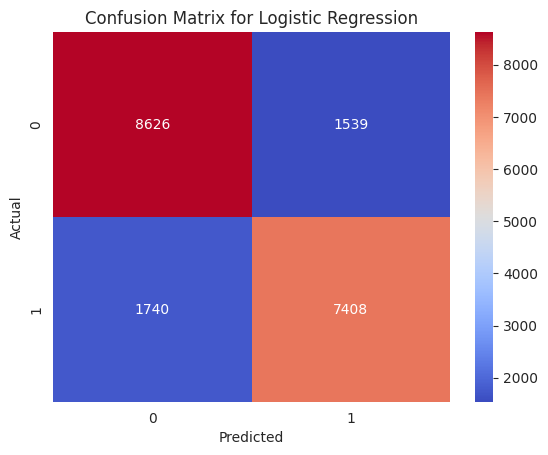

In [13]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

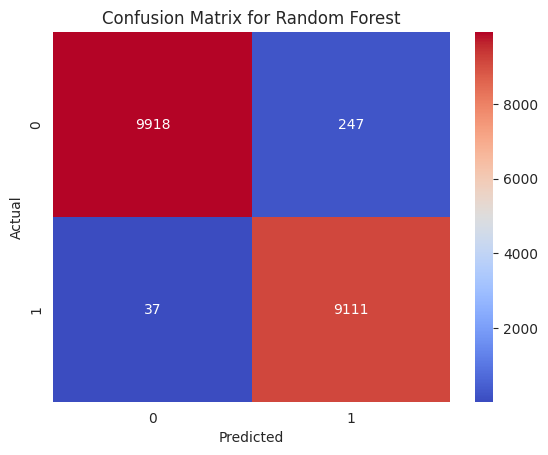

In [14]:
cm = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot=True,fmt='d',cmap='coolwarm')
plt.title('Confusion Matrix for Random Forest')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5)  # 5-fold CV
print("Cross-validation scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())


Cross-validation scores: [0.98469903 0.98850485 0.98415534 0.98928155 0.98562995]
Mean CV Score: 0.9864541457079898


In [16]:
# Fit the pipeline
rf.fit(x_train, y_train)

# Extract feature importances from the classifier
rf_model = rf.named_steps["classifier"]
feat_importance = rf_model.feature_importances_

# Get transformed feature names from the full preprocessor
feature_names = rf.named_steps["preprocessor"].get_feature_names_out()

# Sort and display
import numpy as np

indices = np.argsort(feat_importance)[::-1]
print("🔍 Top Feature Importances:")
for i in indices:
    print(f"{feature_names[i]}: {feat_importance[i]:.4f}")


🔍 Top Feature Importances:
num__delay_x_calls: 0.2983
num__delay_ratio: 0.1929
num__Support Calls: 0.0909
num__Gender: 0.0786
num__Tenure: 0.0598
num__calls_per_month: 0.0534
num__Usage Frequency: 0.0489
num__usage_per_month: 0.0396
num__Age: 0.0323
num__Contract Length: 0.0298
num__tenure_x_usage: 0.0265
num__log_total_spend: 0.0240
num__Total Spend: 0.0210
num__Last Interaction: 0.0025
num__Subscription Type: 0.0014


In [17]:
# Save Model
joblib.dump(rf, "churn_model.pkl")
print("Model saved as churn_model.pkl")

Model saved as churn_model.pkl
